# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 17     |  |
| :-------------|:-------------|
| Shannon Werleman| 6292933 |
| Max Feijtes| 6498396 |
| Damien vogelpoel| 6438431 |

| Planning Groep: 17     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12:15 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:30 |
| Pauze 1| 12:45-13:45 |
| Pauze 2| 14:45-14:30 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](Shannon_Idee.jpeg "analyse: ideeen")     

![Alt](Kracht_Mag_Damien.jpg "analyse: ideeen")

![Alt](LDR_Damien.jpg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Magneetveld | Magneetveld detectie | Sensor kan een magnetische cilinder met hoogte 8mm en diameter 5mm en remanent veld $B_r$ van 1.28 +- 0.18 T detecteren op een maximale afstand van 0,5 +- 0,1 cm |
|Magneetveld | Magneetveld detectie | Sensor kan blootgesteld worden met een magnetische cilinder met hoogte 8mm en diameter 5mm en remanent veld $B_r$ van 1.28 +- 0.18 T op een afstand van 0,5 +- 0,1 cm of hoger zonder permanente schade te ondervinden |
|Magneetveld | Magneetveld detectie | De sensor moet op zijn minst iedere 0,1 s meten. |
|LDR | Lichtintensiteit bepaling | Sensor kan minimaal 2500 +- 100 Lux detecteren op 5 +- 0,1 cm van de bron  |
|LDR | Lichtintensiteit bepaling | Sensor heeft voldoende gevoeligheid om kleine veranderingen van 5 lux te detecteren |
|LDR | Lichtintensiteit bepaling | De sensor kan werken tot 5V |
|Kracht Sensor | Weegschaal | De sensor moet minimaal 10 N +- 0,5 N kunnen detecteren |
|Kracht Sensor | Weegschaal | De sensor moet maximaal 1 kN +- 0,5 N kunnen zonder permanente schade te ondervinden |
|Kracht Sensor | Weegschaal | De sensor moet een stabiele meting geven zonder schommeling +- 2N |

Groep 17 heeft gekozen voor sensor Magneetveld Sensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Opstelling1.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen?   
De afstand tussen onze sensor en het grondvlak van een magnetische cilinder met hoogte 8mm en diameter 5mm en remanent veld $B_r$ van 1.28 +- 0.18 T van bekende specificaties.        
2. Over welk bereik ga je deze variabelen veranderen?       
Van 3 to 0,5 +- 0,1 cm. De meting begint bij 3 cm. Vervolgens wordt de magneet verschoven met 0.1 cm naar 0,5 cm toe.   
3. Wat ga je allemaal meten?   
De afstand van de magneet tot de sensor en de voltage die het geeft.     
4. Hoeveel metingen ga je doen?    
We doen een meting.
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?     
Ja, met deze metingen kan geconcludeerd worden dat de sensor wel of niet geschikt is voor de gekozen toepassing. 


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Opstelling2.jpg "meetopstelling student")



 Hierboven is de opstelling van de magneetveldsensor te zien. Voor de sensor is een meetlint geplaatst om af te kunnen lezen op welke afstand de magneet zich bevindt. De magneet is met plakband aan een stokje bevestigd, zodat deze tijdens de meting makkerlijker kan schuiven. Achter de sensor is een stuk karton geplaatst om te voorkomen dat er interferentie optreedt door de draden die zich daarachter bevinden.


## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

distance = np.array([30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0.5], dtype=float)
u_d = 1
activation = 1024 - np.array([520, 518, 519, 519, 520, 521, 520, 522, 522, 522, 524, 527, 530, 530, 534, 535, 540, 542, 546, 549, 560, 570, 575, 586, 603, 624, 660, 695, 710, 742, 770], dtype=float)

[-0.07142785]


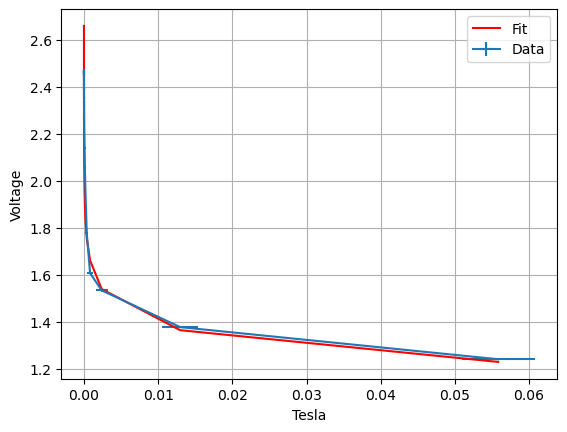

In [2]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.


R = 0.0025   
L = 0.008    
Br = 1.275    

def Bz(z):
    z_m = z * 0.01 
    left = (z_m + L) / np.sqrt((z_m + L)**2 + R**2)
    right = z_m / np.sqrt(z_m**2 + R**2)
    return 0.5 * Br * (left - right)

def Voltage(a):
    return 5*a/1024

def Exp(x, a):
    return x**a

p_opt, pcov = curve_fit(Exp, Bz(distance), Voltage(activation), p0=[-1], bounds=(-5, 5))
print(p_opt)

u_Bz = Bz(distance + u_d)

plt.figure()
plt.errorbar(Bz(distance), Voltage(activation), xerr=u_Bz, yerr=(5/1024), label='Data')
plt.plot(Bz(distance), Exp(Bz(distance), *p_opt), 'r-', label='Fit')
plt.xlabel("Tesla")
plt.ylabel("Voltage")
plt.legend()
plt.grid()
plt.show()

## *Opdracht 7*: Iteratie nodig?


Oorspronkelijk wouden we het magneetveld uit een draad willen meten, als draadloze ampere meter. Uit simulatie bleek dit onredelijk te zijn met het beschikbare materiaal (Voor het meetbaar maken van de stroom, zou een weerstand van ±0.2ohm of een spoel bestaande uit 16 meter draad nodig zijn). We zijn teruggestapt in het ontwerpproces, en hebben gekozen voor kalibratie en verificatie op basis van magneten. Hieruit is de rest van deze meting gebleken - waarbij we kiezen voor het varieren van de afstand tussen de magneet en de hall sensor inplaats van het varieren van het voltage door een stroomdraad. 

## *Opdracht 8*: Conclusie, leerdoel

De gebruikte hall sensor is geschikt voor het meten van het magneetveld met de gestelde kriteria. Uit de waarde blijkt ook dat het inderdaad niet gevoelig genoeg zou zijn voor het meten van de stroom met de beschikbare onderdelen en tijd.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Opstelling2.jpg "meetopstelling student")



 Hierboven is de opstelling van de magneetveldsensor te zien. Voor de sensor is een meetlint geplaatst om af te kunnen lezen op welke afstand de magneet zich bevindt. De magneet is met plakband aan een stokje bevestigd, zodat deze tijdens de meting makkerlijker kan schuiven. Achter de sensor is een stuk karton geplaatst om te voorkomen dat er interferentie optreedt door de draden die zich daarachter bevinden.


### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Magneetveld | Magneetveld detectie | Sensor kan een magnetische cilinder met hoogte 8mm en diameter 5mm en remanent veld $B_r$ van 1.28 +- 0.18 T detecteren op een maximale afstand van 0,5 +- 0,1 cm |
|Magneetveld | Magneetveld detectie | Sensor kan blootgesteld worden met een magnetische cilinder met hoogte 8mm en diameter 5mm en remanent veld $B_r$ van 1.28 +- 0.18 T op een afstand van 0,5 +- 0,1 cm of hoger zonder permanente schade te ondervinden |
|Magneetveld | Magneetveld detectie | De sensor moet op zijn minst iedere 0,1 s meten. |
|LDR | Lichtintensiteit bepaling | Sensor kan minimaal 2500 +- 100 Lux detecteren op 5 +- 0,1 cm van de bron  |
|LDR | Lichtintensiteit bepaling | Sensor heeft voldoende gevoeligheid om kleine veranderingen van 5 lux te detecteren |
|LDR | Lichtintensiteit bepaling | De sensor kan werken tot 5V |
|Kracht Sensor | Weegschaal | De sensor moet minimaal 10 N +- 0,5 N kunnen detecteren |
|Kracht Sensor | Weegschaal | De sensor moet maximaal 1 kN +- 0,5 N kunnen zonder permanente schade te ondervinden |
|Kracht Sensor | Weegschaal | De sensor moet een stabiele meting geven zonder schommeling +- 2N |

Groep 17 heeft gekozen voor sensor Magneetveld Sensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

[-0.07142785]


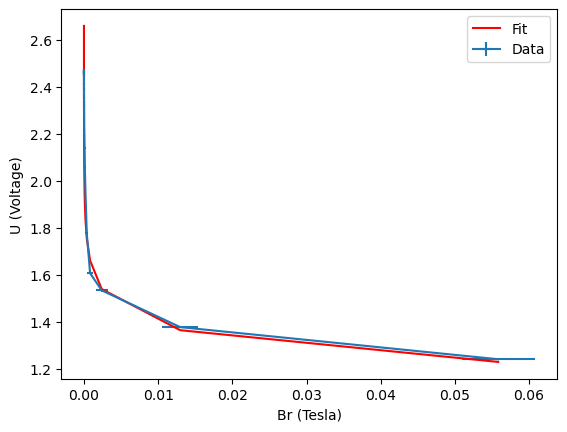

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

distance = np.array([30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0.5], dtype=float)
u_d = 1
activation = 1024 - np.array([520, 518, 519, 519, 520, 521, 520, 522, 522, 522, 524, 527, 530, 530, 534, 535, 540, 542, 546, 549, 560, 570, 575, 586, 603, 624, 660, 695, 710, 742, 770], dtype=float)


R = 0.0025   
L = 0.008    
Br = 1.275    

def Bz(z):
    z_m = z * 0.01 
    left = (z_m + L) / np.sqrt((z_m + L)**2 + R**2)
    right = z_m / np.sqrt(z_m**2 + R**2)
    return 0.5 * Br * (left - right)

def Voltage(a):
    return 5*a/1024

def Exp(x, a):
    return x**a

p_opt, pcov = curve_fit(Exp, Bz(distance), Voltage(activation), p0=[-1], bounds=(-5, 5))
print(p_opt)

u_Bz = Bz(distance + u_d)

plt.figure()
plt.errorbar(Bz(distance), Voltage(activation), xerr=u_Bz, yerr=(5/1024), label='Data')
plt.plot(Bz(distance), Exp(Bz(distance), *p_opt), 'r-', label='Fit')
plt.xlabel("Br (Tesla)")
plt.ylabel("U (Voltage)")
plt.legend()
plt.show()

 ![Alt](Grrafiek.png "meetopstelling student")

 

Aan de hand van de gebruikte opstelling, in combinatie van de data analyse, hebben we de sensitiviteit van de hall sensor kunnen bepalen. We hebben daarmee onder andere geverifieerd dat ons initiele ontwerpcyclus (Opstelling en meetdoel -> Bepalen van haalbaarheid aan de hand van berekeningen -> Beslissen en aanpassen aan de mogelijkheden) juist was verlopen.